In [1]:
!git clone https://github.com/Bob05757/Renewable-energy-generation-input-feature-variables-analysis

Cloning into 'Renewable-energy-generation-input-feature-variables-analysis'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 51 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 149.90 MiB | 25.12 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Conv1D, Dropout, Bidirectional, Multiply,
    Permute, Flatten, RepeatVector, Lambda, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
import pandas as pd
import numpy as np
# Attention Mechanism
def attention_3d_block(inputs, single_attention_vector=False):
    time_steps = tf.keras.backend.int_shape(inputs)[1]
    input_dim = tf.keras.backend.int_shape(inputs)[2]

    a = Permute((2, 1))(inputs)
    a = Dense(time_steps, activation='softmax')(a)

    if single_attention_vector:
        a = GlobalAveragePooling1D()(a)
        a = RepeatVector(input_dim)(a)

    a_probs = Permute((2, 1))(a)
    output_attention_mul = Multiply()([inputs, a_probs])

    return output_attention_mul

# Model function
def attention_model():
    inputs = Input(shape=(TIME_STEPS, INPUT_DIMS))

    x = Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = Dropout(0.3)(x)

    lstm_out = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
    lstm_out = Dropout(0.3)(lstm_out)

    attention_mul = attention_3d_block(lstm_out)
    attention_mul = Flatten()(attention_mul)

    output = Dense(1, activation='sigmoid')(attention_mul)
    model = Model(inputs=[inputs], outputs=output)

    return model

# Reverse normalization function
def FNormalizeMult(data, normalize):
    data = np.array(data)
    for i in range(data.shape[1]):
        listlow, listhigh = normalize[i, 0], normalize[i, 1]
        delta = listhigh - listlow
        if delta != 0:
            data[:, i] = data[:, i] * delta + listlow

    return data

# Normalize function
def NormalizeMult(data):
    data = np.array(data)
    normalize = np.zeros((data.shape[1], 2))

    for i in range(data.shape[1]):
        listlow, listhigh = np.percentile(data[:, i], [0, 100])
        normalize[i, 0] = listlow
        normalize[i, 1] = listhigh
        delta = listhigh - listlow
        if delta != 0:
            data[:, i] = (data[:, i] - listlow) / delta

    return data, normalize

# Create dataset function
def create_dataset(dataset, look_back):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :]
        dataX.append(a)
        dataY.append(dataset[i + look_back, :])

    return np.array(dataX), np.array(dataY)


In [3]:
# 由renewable ... 项目可知， Atmosphere (hpa) Air_P的相关系数最小，可以剔除。另外，关于时间的东西，可用youtube项目参考,有个三角函数处理
# data = pd.read_csv("/content/Renewable-energy-generation-input-feature-variables-analysis/data_processed/solar_stations/Solarstationsite7(Nominalcapacity-30MW).xlsx")

Dataset_SS_site7 = pd.read_excel(r'/content/Renewable-energy-generation-input-feature-variables-analysis/data_processed/solar_stations/Solar station site 7 (Nominal capacity-30MW).xlsx'
                                ).drop(index=0)


In [4]:
Dataset_SS_site7.columns=['Time','TSI','DNI','GHI','Air_T','Air_P','Air_H','Power(MW)']

In [5]:
Dataset_SS_site7.drop(columns=['Air_P','Air_T', 'Air_H'],inplace=True)

In [6]:
Dataset_SS_site7.head()

,Time,TSI,DNI,GHI,Power(MW)
1,2019-01-01 00:15:00,0.0,0.0,0.0,0.0
2,2019-01-01 00:30:00,0.0,0.0,0.0,0.0
3,2019-01-01 00:45:00,0.0,0.0,0.0,0.0
4,2019-01-01 01:00:00,0.0,0.0,0.0,0.0
5,2019-01-01 01:15:00,0.0,0.0,0.0,0.0


# 时间转成周期性

In [7]:
df = Dataset_SS_site7
df.index = pd.to_datetime(df['Time'], format='%d.%m.%Y %H:%M:%S')

In [8]:
temp = df['Power(MW)']
df['Seconds'] = df.index.map(pd.Timestamp.timestamp)
df

,Time,TSI,DNI,GHI,Power(MW),Seconds
Time,,,,,,
2019-01-01 00:15:00,2019-01-01 00:15:00,0.0,0.000000,0.0,0.0,1.546302e+09
2019-01-01 00:30:00,2019-01-01 00:30:00,0.0,0.000000,0.0,0.0,1.546303e+09
2019-01-01 00:45:00,2019-01-01 00:45:00,0.0,0.000000,0.0,0.0,1.546304e+09
2019-01-01 01:00:00,2019-01-01 01:00:00,0.0,0.000000,0.0,0.0,1.546304e+09
2019-01-01 01:15:00,2019-01-01 01:15:00,0.0,0.000000,0.0,0.0,1.546305e+09
...,...,...,...,...,...,...
2020-12-31 22:45:00,2020-12-31 22:45:00,0.0,0.000000,0.0,0.0,1.609455e+09
2020-12-31 23:00:00,2020-12-31 23:00:00,0.0,0.000000,0.0,0.0,1.609456e+09
2020-12-31 23:15:00,2020-12-31 23:15:00,0.0,0.066667,0.0,0.0,1.609456e+09


In [9]:
day = 60*60*24
year = 365.2425*day

df['Day sin'] = np.sin(df['Seconds'] * (2* np.pi / day))
df['Day cos'] = np.cos(df['Seconds'] * (2 * np.pi / day))
df['Year sin'] = np.sin(df['Seconds'] * (2 * np.pi / year))
df['Year cos'] = np.cos(df['Seconds'] * (2 * np.pi / year))
df.head()  # TODO 新增的几列计算相关性，可能只有hour是可以采取的

,Time,TSI,DNI,GHI,Power(MW),Seconds,Day sin,Day cos,Year sin,Year cos
Time,,,,,,,,,,
2019-01-01 00:15:00,2019-01-01 00:15:00,0.0,0.0,0.0,0.0,1.546302e+09,0.065403,0.997859,0.002201,0.999998
2019-01-01 00:30:00,2019-01-01 00:30:00,0.0,0.0,0.0,0.0,1.546303e+09,0.130526,0.991445,0.002380,0.999997
2019-01-01 00:45:00,2019-01-01 00:45:00,0.0,0.0,0.0,0.0,1.546304e+09,0.195090,0.980785,0.002559,0.999997
2019-01-01 01:00:00,2019-01-01 01:00:00,0.0,0.0,0.0,0.0,1.546304e+09,0.258819,0.965926,0.002738,0.999996
2019-01-01 01:15:00,2019-01-01 01:15:00,0.0,0.0,0.0,0.0,1.546305e+09,0.321439,0.946930,0.002917,0.999996


In [10]:
df.drop(columns=['Seconds','Year sin', 'Year cos', 'Time'],inplace=True)
# df.drop(columns=['Time'], inplace=True)
df

,TSI,DNI,GHI,Power(MW),Day sin,Day cos
Time,,,,,,
2019-01-01 00:15:00,0.0,0.000000,0.0,0.0,0.065403,0.997859
2019-01-01 00:30:00,0.0,0.000000,0.0,0.0,0.130526,0.991445
2019-01-01 00:45:00,0.0,0.000000,0.0,0.0,0.195090,0.980785
2019-01-01 01:00:00,0.0,0.000000,0.0,0.0,0.258819,0.965926
2019-01-01 01:15:00,0.0,0.000000,0.0,0.0,0.321439,0.946930
...,...,...,...,...,...,...
2020-12-31 22:45:00,0.0,0.000000,0.0,0.0,-0.321439,0.946930
2020-12-31 23:00:00,0.0,0.000000,0.0,0.0,-0.258819,0.965926
2020-12-31 23:15:00,0.0,0.066667,0.0,0.0,-0.195090,0.980785


In [11]:
# Assuming 'Power(MW)' is the actual column name
power_col = df.pop('Power(MW)')  # Remove 'Power(MW)' column and store it
df.insert(0, 'Power(MW)', power_col)  # Insert it at the beginning (index 0)

In [12]:
df

,Power(MW),TSI,DNI,GHI,Day sin,Day cos
Time,,,,,,
2019-01-01 00:15:00,0.0,0.0,0.000000,0.0,0.065403,0.997859
2019-01-01 00:30:00,0.0,0.0,0.000000,0.0,0.130526,0.991445
2019-01-01 00:45:00,0.0,0.0,0.000000,0.0,0.195090,0.980785
2019-01-01 01:00:00,0.0,0.0,0.000000,0.0,0.258819,0.965926
2019-01-01 01:15:00,0.0,0.0,0.000000,0.0,0.321439,0.946930
...,...,...,...,...,...,...
2020-12-31 22:45:00,0.0,0.0,0.000000,0.0,-0.321439,0.946930
2020-12-31 23:00:00,0.0,0.0,0.000000,0.0,-0.258819,0.965926
2020-12-31 23:15:00,0.0,0.0,0.066667,0.0,-0.195090,0.980785


In [13]:
def df_to_X_y(df, window_size=24):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size][0]  # 看清楚power是第几列的 需要调整
    y.append(label)
  return np.array(X), np.array(y)

In [14]:
WINDOW_SIZE = 24
X1, y1 = df_to_X_y(df, WINDOW_SIZE)
X1.shape, y1.shape

((70151, 24, 6), (70151,))

In [15]:
df = df[3::4]
df

,Power(MW),TSI,DNI,GHI,Day sin,Day cos
Time,,,,,,
2019-01-01 01:00:00,0.0,0.0,0.0,0.0,0.258819,0.965926
2019-01-01 02:00:00,0.0,0.0,0.0,0.0,0.500000,0.866025
2019-01-01 03:00:00,0.0,0.0,0.0,0.0,0.707107,0.707107
2019-01-01 04:00:00,0.0,0.0,0.0,0.0,0.866025,0.500000
2019-01-01 05:00:00,0.0,0.0,0.0,0.0,0.965926,0.258819
...,...,...,...,...,...,...
2020-12-31 19:00:00,0.0,0.0,0.0,0.0,-0.965926,0.258819
2020-12-31 20:00:00,0.0,0.0,0.0,0.0,-0.866025,0.500000
2020-12-31 21:00:00,0.0,0.0,0.0,0.0,-0.707107,0.707107


In [16]:
X_train, y_train = X1[:14000], y1[:14000]
X_val, y_val = X1[14000:15760], y1[14000:15760]
X_test, y_test = X1[15760:], y1[15760:]
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((14000, 24, 6), (14000,), (1760, 24, 6), (1760,), (54391, 24, 6), (54391,))

In [17]:
temp_training_mean = np.mean(X_train[:, :, 0])
temp_training_std = np.std(X_train[:, :, 0])

def preprocess(X):
  X[:, :, 0] = (X[:, :, 0] - temp_training_mean) / temp_training_std
  return X

In [18]:
preprocess(X_train)
preprocess(X_val)
preprocess(X_test)

array([[[-7.18431984e-01,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  8.96872742e-01,  4.42288690e-01],
        [-7.18431984e-01,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  9.23879533e-01,  3.82683432e-01],
        [-7.18431984e-01,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  9.46930129e-01,  3.21439465e-01],
        ...,
        [-1.12159814e-02,  2.21866667e+02,  1.80209333e+02,
          2.03266667e+02,  6.08761429e-01, -7.93353340e-01],
        [ 1.43882380e-01,  2.61733333e+02,  2.12527333e+02,
          2.49133333e+02,  5.55570233e-01, -8.31469612e-01],
        [ 2.43043676e-01,  2.92400000e+02,  2.37158000e+02,
          2.58733333e+02,  5.00000000e-01, -8.66025404e-01]],

       [[-7.18431984e-01,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  9.23879533e-01,  3.82683432e-01],
        [-7.18431984e-01,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  9.46930129e-01,  3.21439465e-01],
        [-7.18431

In [19]:
INPUT_DIMS = 6
TIME_STEPS = 24
lstm_units = 64

# Normalize data
data, normalize = NormalizeMult(df)

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
model = Sequential()
model.add(InputLayer((WINDOW_SIZE, 6)))
model.add(Conv1D(256, kernel_size=24, activation='relu'))
model.add(Flatten())
model.add(Dense(16, 'relu'))
model.add(Dense(1, 'linear'))
model.summary()

cp = ModelCheckpoint('model_CNN.keras', save_best_only=True)
model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

NameError: name 'WINDOW_SIZE' is not defined

In [28]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=250, callbacks=[cp])

Epoch 1/250
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 105.2378 - root_mean_squared_error: 9.1503 - val_loss: 6.1354 - val_root_mean_squared_error: 2.4770
Epoch 2/250
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.8531 - root_mean_squared_error: 2.8015 - val_loss: 5.4846 - val_root_mean_squared_error: 2.3419
Epoch 3/250
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.7256 - root_mean_squared_error: 2.5895 - val_loss: 6.2332 - val_root_mean_squared_error: 2.4966
Epoch 4/250
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.1997 - root_mean_squared_error: 2.4873 - val_loss: 4.8836 - val_root_mean_squared_error: 2.2099
Epoch 5/250
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0679 - root_mean_squared_error: 2.4586 - val_loss: 3.7784 - val_root_mean_squared_error: 1.9438
Epoch 6/250
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.4543 - root_mean_squared_error: 2.7210 - val_loss: 4.4096 - val_root_mean_squared_error: 2.0999
Epoch 7/250
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [30]:
from tensorflow.keras.models import load_model
model = load_model('model_CNN.keras')
train_predictions = model.predict(X_train).flatten()

val_predictions = model.predict(X_val).flatten()

test_predictions = model.predict(X_test).flatten()

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance Metrics:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    # 修改MAPE计算，避免除以0的情况
    # 方法1：只计算非零值的MAPE
    non_zero_mask = y_true != 0
    if np.any(non_zero_mask):
        mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
        print(f"MAPE (excluding zeros): {mape:.2f}%")

    # 方法2：使用SMAPE (对称平均绝对百分比误差)
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100
    print(f"SMAPE: {smape:.2f}%")

In [ ]:
# Evaluate on all datasets
print("Training Set Evaluation:")
evaluate_model(y_train, model.predict(X_train), "Model (CNN)")

print("\nValidation Set Evaluation:")
evaluate_model(y_val, model.predict(X_val), "Model (CNN)")

print("\nTest Set Evaluation:")
evaluate_model(y_test, model.predict(X_test), "Model (CNN)")

# Visualize actual vs predicted values scatter plot for Power predictions
plt.figure(figsize=(10, 6))
test_predictions = model.predict(X_test)
plt.scatter(y_test[:, 1], test_predictions[:, 1], alpha=0.5)
plt.plot([y_test[:, 1].min(), y_test[:, 1].max()],
         [y_test[:, 1].min(), y_test[:, 1].max()], 'r--', lw=2)
plt.xlabel('Actual Power Values')
plt.ylabel('Predicted Power Values')
plt.title('Model (CNN): Actual vs Predicted Power Values')
plt.tight_layout()
plt.show()

Training Set Evaluation:
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Model (CNN) Performance Metrics:
MAE: 0.8312
RMSE: 1.7752
R² Score: 0.9603
MAPE (excluding zeros): 685.38%
SMAPE: 173.94%

Validation Set Evaluation:
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Model (CNN) Performance Metrics:
MAE: 0.8961
RMSE: 1.8867
R² Score: 0.9412
MAPE (excluding zeros): 587.58%
SMAPE: 169.66%

Test Set Evaluation:
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Model (CNN) Performance Metrics:
MAE: 4.7996
RMSE: 11.2711
R² Score: -1.0932
MAPE (excluding zeros): 621.61%


# 去掉时间，临时方案

In [5]:
data = Dataset_SS_site7.drop(['Time', 'Air_P'], axis=1)
data
# Dataset_SS_site7

,TSI,DNI,GHI,Air_T,Air_H,Power(MW)
1,0.0,0.000000,0.0,4.600000,40.766667,0.0
2,0.0,0.000000,0.0,4.600000,40.946667,0.0
3,0.0,0.000000,0.0,4.600000,43.413333,0.0
4,0.0,0.000000,0.0,1.946667,51.386667,0.0
5,0.0,0.000000,0.0,2.400000,49.713333,0.0
...,...,...,...,...,...,...
70171,0.0,0.000000,0.0,10.010667,14.941333,0.0
70172,0.0,0.000000,0.0,9.577333,15.282000,0.0
70173,0.0,0.066667,0.0,9.730000,14.540667,0.0
70174,0.0,0.000000,0.0,9.886000,13.902667,0.0


In [7]:
INPUT_DIMS = 6
TIME_STEPS = 20
lstm_units = 64

# Normalize data
data, normalize = NormalizeMult(data)

In [8]:
power_data = data[:, 5].reshape(len(data), 1)
power_data

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]])

In [9]:
train_X, _ = create_dataset(data, TIME_STEPS)
_, train_Y = create_dataset(power_data, TIME_STEPS)

In [10]:
train_X

array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.57779925e-01,
         3.92106686e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.57779925e-01,
         3.93925113e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.57779925e-01,
         4.18844287e-01, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.93795436e-01,
         5.30980602e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.70528349e-01,
         5.43305494e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.64711577e-01,
         5.47952584e-01, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.57779925e-01,
         3.93925113e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.57779925e-01,
         4.18844287e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.806107

In [11]:
model = attention_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 20, 6)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 20, 64)         │            448 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 20, 64)         │              0 │ conv1d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 20, 128)        │         66,048 │ dropout[0][0]          │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 20, 128)        │              0 │ bidirectional[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute (Permute)         │ (None, 128, 20)        │              0 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128, 20)        │            420 │ permute[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_1 (Permute)       │ (None, 20, 128)        │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 20, 128)        │              0 │ dropout_1[0][0],       │
│                           │                        │                │ permute_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 2560)           │              0 │ multiply[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1)              │          2,561 │ flatten[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 69,477 (271.39 KB)

 Trainable params: 69,477 (271.39 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam', loss='mse')
model.fit(train_X, train_Y, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 20, 6))
  warnings.warn(msg)


987/987 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0317 - val_loss: 0.0041
Epoch 2/10
987/987 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0050 - val_loss: 0.0035
Epoch 3/10
987/987 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0046 - val_loss: 0.0028
Epoch 4/10
987/987 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0043 - val_loss: 0.0028
Epoch 5/10
987/987 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0043 - val_loss: 0.0024
Epoch 6/10
987/987 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0040 - val_loss: 0.0025
Epoch 7/10
987/987 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0040 - val_loss: 0.0023
Epoch 8/10
987/987 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0041 - val_loss: 0.0023
Epoch 9/10
987/987 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0040 - val_loss: 0.0022
Epoch 10/10
987/987 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0040 - val_loss: 0.0022


In [13]:
model.save('model.h5')

In [14]:
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError

model = load_model('model.h5', custom_objects={'mse': MeanSquaredError()})
train_Y = train_Y.flatten()  # Or train_Y = train_Y.reshape(-1)
# Generate predictions using the loaded model
train_predictions = model.predict(train_X)
train_results = pd.DataFrame(data={'Train Predictions': train_predictions.flatten(), 'Actuals': train_Y})

2193/2193 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [ ]:
train_predictions

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.57779925e-01,
        3.92106686e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.57779925e-01,
        3.93925113e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.57779925e-01,
        4.18844287e-01, 0.00000000e+00],
       ...,
       [0.00000000e+00, 6.08608727e-05, 0.00000000e+00, 4.06980120e-01,
        1.27161914e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.11517202e-01,
        1.20716601e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.10470183e-01,
        1.18184270e-01, 0.00000000e+00]])

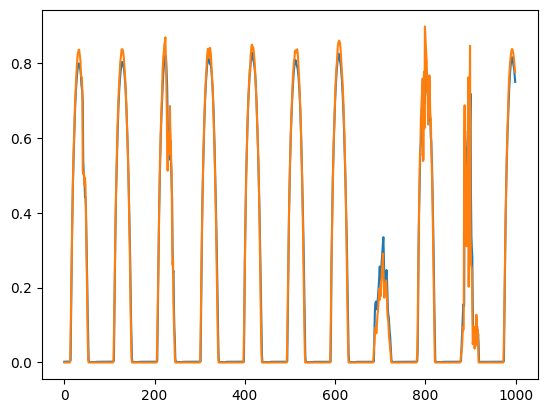

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_results['Train Predictions'][:1000])
plt.plot(train_results['Actuals'][:1000])

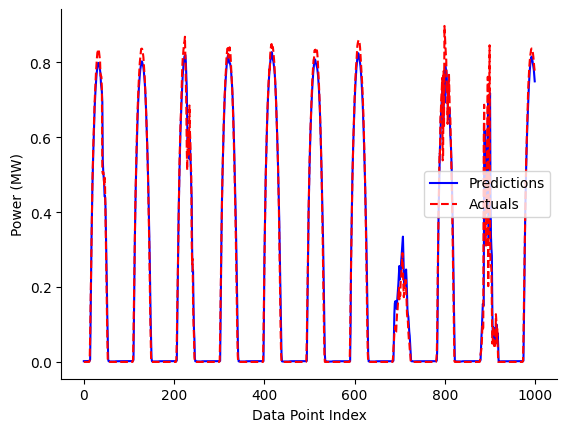

<Figure size 1000x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Create the plot
plt.plot(train_results['Train Predictions'][:1000], label='Predictions', color='blue')  # Predictions in blue
plt.plot(train_results['Actuals'][:1000], label='Actuals', color='red', linestyle='--')  # Actuals in dashed red

# Remove spines (borders)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add labels and legend
plt.xlabel('Data Point Index')  # X-axis label
plt.ylabel('Power (MW)')  # Y-axis label (assuming your data represents power in MW)
plt.legend()  # Show the legend to distinguish lines

# Make the plot a bit larger
plt.figure(figsize=(10, 6))

# Display the plot
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance Metrics:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

In [17]:
evaluate_model(train_Y, train_predictions, "Attention Model")


Attention Model Performance Metrics:
MAE: 0.0271
RMSE: 0.0598
R² Score: 0.9509


## 导入测试集

In [57]:
Dataset_SS_site8 = pd.read_excel(r'/content/Renewable-energy-generation-input-feature-variables-analysis/data_processed/solar_stations/Solar station site 8 (Nominal capacity-30MW).xlsx'
                                ).drop(index=0)

In [59]:
Dataset_SS_site8.columns=['Time','TSI','DNI','GHI','Air_T','Air_P','Air_H','Power(MW)']
test_df = Dataset_SS_site8.drop(['Time', 'Air_P'], axis=1)[:17500]
test_df

,TSI,DNI,GHI,Air_T,Air_H,Power(MW)
1,0.00,0.00,0.00,1.23,88.41,0.00
2,0.00,0.00,0.00,1.44,83.10,0.00
3,0.00,0.00,0.00,1.47,72.45,0.00
4,0.00,0.00,0.00,1.70,87.07,0.00
5,0.00,0.00,0.00,1.73,85.49,0.00
...,...,...,...,...,...,...
17496,17.15,14.92,2.23,24.96,96.60,0.58
17497,31.99,27.83,4.16,23.98,99.88,1.00
17498,44.11,38.37,5.73,26.36,100.00,1.27
17499,61.86,53.82,8.04,26.86,99.84,1.94


In [66]:
test_df['Power(MW)']

,Power(MW)
1,0.00
2,0.00
3,0.00
4,0.00
5,0.00
...,...
17496,0.58
17497,1.00
17498,1.27
17499,1.94


In [60]:
test_data, normalize = NormalizeMult(test_df)
test_power_data = test_data[:, 5].reshape(len(test_data), 1)
test_power_data

array([[0.        ],
       [0.        ],
       [0.        ],
       ...,
       [0.04318259],
       [0.06596396],
       [0.10132608]])

In [61]:
test_X, _ = create_dataset(test_data, TIME_STEPS)
_, test_Y = create_dataset(test_power_data, TIME_STEPS)

In [62]:
test_predictions = model.predict(test_X)

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [63]:
test_Y = test_Y.flatten()
test_results = pd.DataFrame(data={'Train Predictions': test_predictions.flatten(), 'Actuals': test_Y})

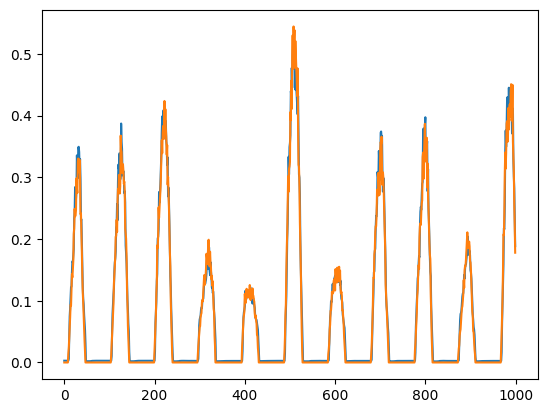

In [64]:
import matplotlib.pyplot as plt
plt.plot(test_results['Train Predictions'][:1000])
plt.plot(test_results['Actuals'][:1000])

In [78]:
# Assuming 'test_results' contains the normalized predictions and 'normalize' contains the normalization parameters
restored_test_results = FNormalizeMult(test_results, normalize)
restored_test_results

array([[ 3.40757732,  0.        ],
       [ 3.41812017,  0.        ],
       [ 3.42200349,  0.        ],
       ...,
       [ 5.33230104, 35.49302958],
       [40.07846559, 45.07614757],
       [56.16954705, 68.85647739]])

In [80]:
restored_df = pd.DataFrame(restored_test_results, columns=['Predicted_Values', 'Actual_Values'])
restored_df

,Predicted_Values,Actual_Values
0,3.407577,0.000000
1,3.418120,0.000000
2,3.422003,0.000000
3,3.406181,0.000000
4,3.408485,0.000000
...,...,...
17474,2.499387,7.808467
17475,2.971585,20.585957
17476,5.332301,35.493030
17477,40.078466,45.076148


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance Metrics:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

evaluate_model(test_Y, test_predictions, "Attention Model")


Attention Model Performance Metrics:
MAE: 0.0146
RMSE: 0.0276
R² Score: 0.9829


In [55]:
test_power_data

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]])

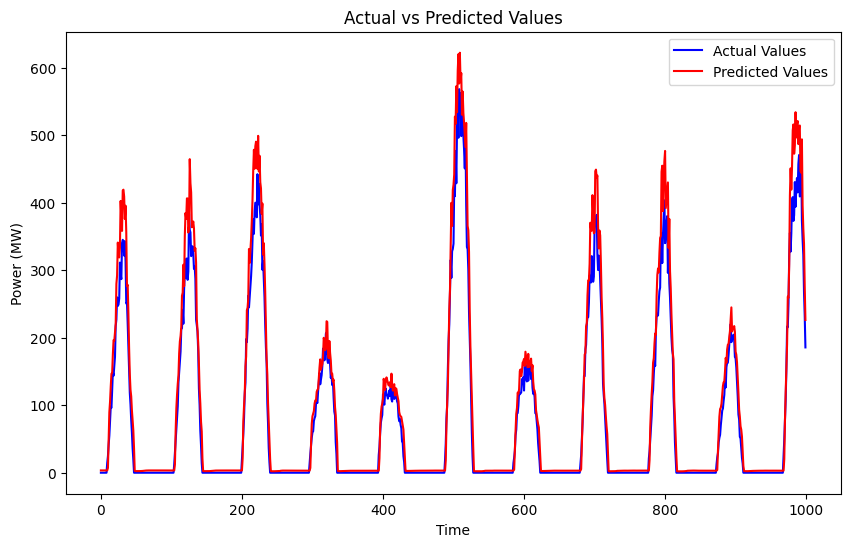

In [84]:
plt.figure(figsize=(10, 6))
plt.plot(restored_df['Actual_Values'][:1000], label='Actual Values', color='blue')
plt.plot(restored_df['Predicted_Values'][:1000], label='Predicted Values', color='red')
plt.xlabel('Time')
plt.ylabel('Power (MW)')  # Assuming Power(MW) is the target variable
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

In [85]:
y_true = restored_df['Actual_Values']
y_pred = restored_df['Predicted_Values']

# Calculate evaluation metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# Print the evaluation results
print(f"\nCNN+BiLSTM+Attention Performance Metrics:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


CNN+BiLSTM+Attention Performance Metrics:
MAE: 21.8969
RMSE: 41.1607
R² Score: 0.9651


# 测试FNormalizeMult

In [41]:
Dataset_SS_site3 = pd.read_excel(r'/content/Renewable-energy-generation-input-feature-variables-analysis/data_processed/solar_stations/Solar station site 3 (Nominal capacity-30MW).xlsx'
                                ).drop(index=0)
Dataset_SS_site3.head()

,Time(year-month-day h:m:s),Total solar irradiance (W/m2),Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Atmosphere (hpa),Relative humidity (%),Power (MW)
1,2019-01-01 00:15:00,0,0,0,1028.7,58.3,-0.0357
2,2019-01-01 00:30:00,0,0,0,1028.7,58.0,-0.0378
3,2019-01-01 00:45:00,0,0,0,1028.6,57.2,-0.0378
4,2019-01-01 01:00:00,0,0,0,1028.6,56.9,-0.0378
5,2019-01-01 01:15:00,0,0,0,1028.4,56.1,-0.0378


In [42]:
Dataset_SS_site3.columns=['Time','TSI','DNI','GHI','Air_P','Air_H','Power(MW)']
df_ = Dataset_SS_site3.drop(['Time', 'Air_P'], axis=1)[:17500]

In [43]:
df_normalize_data, normalize = NormalizeMult(df_)

In [45]:
df_

,TSI,DNI,GHI,Air_H,Power(MW)
1,0,0,0,58.3,-0.035700
2,0,0,0,58.0,-0.037800
3,0,0,0,57.2,-0.037800
4,0,0,0,56.9,-0.037800
5,0,0,0,56.1,-0.037800
...,...,...,...,...,...
17496,51,296,35,67.6,2.063292
17497,79,288,40,66.3,2.898840
17498,127,387,45,65.6,3.661917
17499,182,435,49,66.6,4.043456


In [44]:
df_normalize_data

array([[0.        , 0.        , 0.        , 0.66566265, 0.00091078],
       [0.        , 0.        , 0.        , 0.66114458, 0.00084072],
       [0.        , 0.        , 0.        , 0.64909639, 0.00084072],
       ...,
       [0.1136974 , 0.50921053, 0.06859756, 0.77560241, 0.12427019],
       [0.16293644, 0.57236842, 0.07469512, 0.79066265, 0.13699903],
       [0.20680394, 0.61052632, 0.07621951, 0.77710843, 0.10727471]])

In [46]:
restored_df = FNormalizeMult(df_normalize_data, normalize)
restored_df

array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  5.8300000e+01,
        -3.5700000e-02],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  5.8000000e+01,
        -3.7800000e-02],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  5.7200000e+01,
        -3.7800000e-02],
       ...,
       [ 1.2700000e+02,  3.8700000e+02,  4.5000000e+01,  6.5600000e+01,
         3.6619170e+00],
       [ 1.8200000e+02,  4.3500000e+02,  4.9000000e+01,  6.6600000e+01,
         4.0434555e+00],
       [ 2.3100000e+02,  4.6400000e+02,  5.0000000e+01,  6.5700000e+01,
         3.1524885e+00]])

In [48]:
FNormalizeMult(test_predictions, normalize)

array([[3.3726041],
       [3.3752844],
       [3.3749123],
       ...,
       [2.6947446],
       [2.7612293],
       [2.7815373]], dtype=float32)